# Mercari(일본 중고거래 플랫폼) 가격 예측 프로젝트

## 프로젝트 흐름  
1. 환경 설정 및 데이터 로드
2. 데이터 전처리 (카테고리 분리, 결측치 처리)
3. 텍스트 특징 추출 (NLP_자연어 처리)
4. 새로운 피처 생성
5. 모델 학습
6. 가격 예측 & 제출  

### 1. 환경설정 및 데이터 로드

In [2]:
pip install pandas numpy scikit-learn lightgbm nltk scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# 1. 환경설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. 데이터 로드
train = pd.read_csv('train.tsv', sep='\t')
test  = pd.read_csv('test.tsv',  sep='\t')

print(train.shape)
print(train.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TG\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\TG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\TG\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(1482535, 8)
   train_id                                 name  item_condition_id  \
0         0  MLB Cincinnati Reds T Shirt Size XL                  3   
1         1     Razer BlackWidow Chroma Keyboard                  3   
2         2                       AVA-VIV Blouse                  1   
3         3                Leather Horse Statues                  1   
4         4                 24K GOLD plated rose                  1   

                                       category_name brand_name  price  \
0                                  Men/Tops/T-shirts        NaN   10.0   
1  Electronics/Computers & Tablets/Components & P...      Razer   52.0   
2                        Women/Tops & Blouses/Blouse     Target   10.0   
3                 Home/Home Décor/Home Décor Accents        NaN   35.0   
4                            Women/Jewelry/Necklaces        NaN   44.0   

   shipping                                   item_description  
0         1                                 No des

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [5]:
train.describe()

,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


In [6]:
train['item_condition_id'].unique() # 수치형 컬럼이지만 상태의 등급을 수치로 표현

array([3, 1, 2, 4, 5])

In [7]:
train['shipping'].unique() # 수치형 컬럼이지만 배송 유무에 대한 것을 수치로 표현

array([1, 0])

In [8]:
# 수치형 컬럼 선택
numeric_cols = ['item_condition_id', 'price', 'shipping']

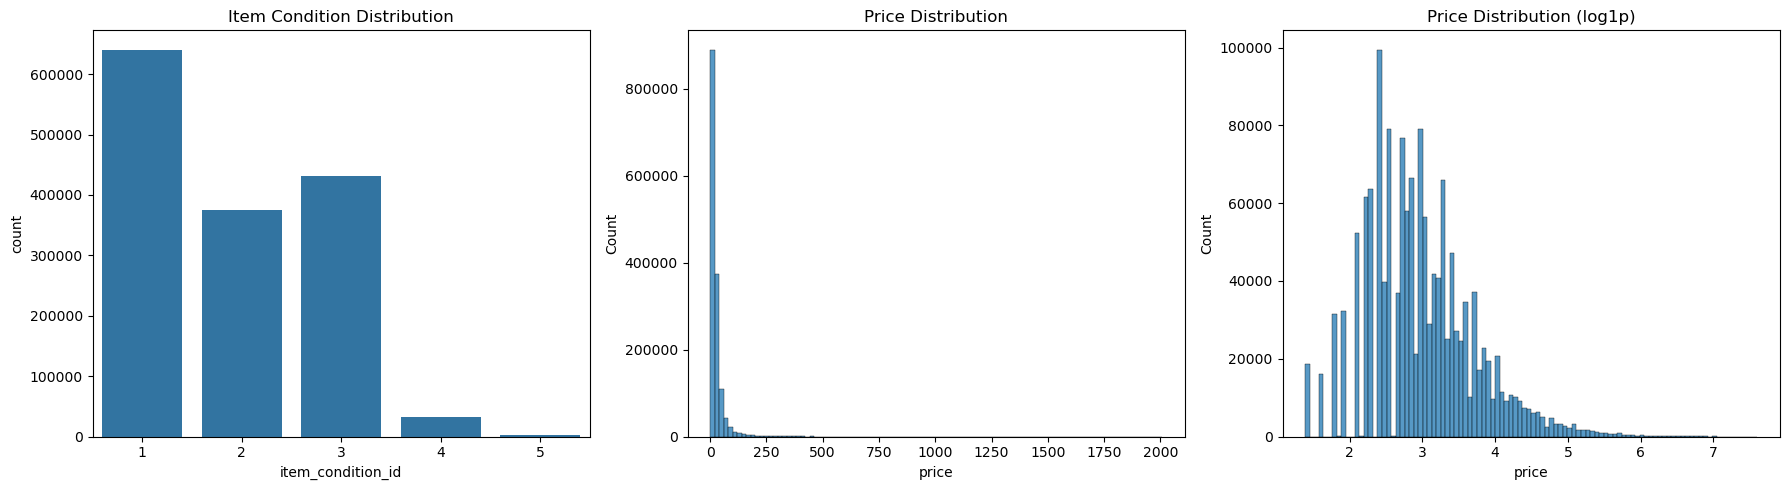

In [9]:
# 수치형 컬럼의 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# item_condition_id: 카테고리형에 가까우므로 countplot
sns.countplot(x='item_condition_id', data=train, ax=axes[0])
axes[0].set_title('Item Condition Distribution')

# price: 가격은 보통 심하게 오른쪽으로 치우쳐 있음 (right-skewed)
sns.histplot(train['price'], bins=100, ax=axes[1])
axes[1].set_title('Price Distribution')

# price 로그 변환 후 확인
sns.histplot(train['price'][train['price'] > 0].apply(np.log1p), bins=100, ax=axes[2])
axes[2].set_title('Price Distribution (log1p)')

plt.tight_layout()
plt.show()

In [10]:
train[train['price'] == 0]

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
1325,1325,Alabama Crimson Tide Quality Lanyard,1,Sports & Outdoors/Fan Shop/NCAA,NaN,0.0,1,TOP QUALITY THICK LANYARD Reversible sides wit...
2544,2544,Levi leggings,3,"Women/Jeans/Slim, Skinny",Levi's®,0.0,0,Light wash. Hardly worn. Size 24 but fits like...
2712,2712,Simple Red Lace Lingerie Top,3,Women/Underwear/G-Strings & Thongs,NaN,0.0,0,"Very simple but cute, a little form fitting as..."
3576,3576,Turquoise 15 Pc Makeup Brush Set,1,Beauty/Tools & Accessories/Makeup Brushes & Tools,NaN,0.0,1,1 left!
3761,3761,Girls size 7/8,3,Kids/Girls (4+)/Tops & T-Shirts,NaN,0.0,1,5 pair gap jean excellent used condition 3 chi...
...,...,...,...,...,...,...,...,...
1474172,1474172,Homecoming or Dama ivory dress,2,"Women/Dresses/Above Knee, Mini",NaN,0.0,0,Ivory formal dress. I wore this dress once for...
1474198,1474198,Tie up flannel top,3,Women/Tops & Blouses/Blouse,NaN,0.0,1,I got this last year and just didnt wear it mu...
1477958,1477958,Rae Dunn Measuring Pear,3,Home/Home Décor/Home Décor Accents,NaN,0.0,0,The dash lid appears it was dropped and a piec...
1478519,1478519,4 pairs women's wool boots socks,1,Women/Shoes/Boots,NaN,0.0,1,✔️SHARE YOUR SOCKS WITH FRIENDS AND FAMILY! ✔️...


In [11]:
# 가격이 0인 데이터가 있는지 꼭 확인
print(f"price == 0 인 행 수: {(train['price'] == 0).sum()}")

price == 0 인 행 수: 874


### 2. 데이터 전처리 (결측치, 이상치)

In [12]:
# 전체 결측치 현황 한눈에 보기
print("=== 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 현황 ===
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


In [13]:
# 세부 컬럼별 결측치 확인
# 'category_name' 컬럼

print(f"\n▣ category_name 결측치 수: {train['category_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['category_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_category = train[train['category_name'].isna()][
    ['name', 'brand_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== category_name 결측 샘플 ===")
print(null_category.to_string())


▣ category_name 결측치 수: 6327
▣ 전체 대비 비율: 0.43%

=== category_name 결측 샘플 ===
                                             name      brand_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         item_description  price
245817                             Mini deep dome         Zoo Med                                                                                                                                                                                                         

In [14]:
# 'brand_name' 컬럼

print(f"\n▣ brand_name 결측치 수: {train['brand_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['brand_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_brand = train[train['brand_name'].isna()][
    ['name', 'category_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== brand_name 결측 샘플 ===")
print(null_brand.to_string())


▣ brand_name 결측치 수: 632682
▣ 전체 대비 비율: 42.68%

=== brand_name 결측 샘플 ===
                                             name                                   category_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                    item_description  price
519130                  Perfume & necklace Bundle                          Beauty/Fragrance/Women                                                                                                                                                                                                                                                                 

In [15]:
# 'item_description' 컬럼

print(f"\n▣ item_description 결측치 수: {train['item_description'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['item_description'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_description = train[train['item_description'].isna()][
    ['name', 'category_name', 'brand_name', 'price']
].sample(6, random_state=42)

print("\n=== item_description 결측 샘플 ===")
print(null_description.to_string())


▣ item_description 결측치 수: 6
▣ 전체 대비 비율: 0.00%

=== item_description 결측 샘플 ===
                            name                                   category_name           brand_name  price
321916        Lululemon leggings  Women/Athletic Apparel/Pants, Tights, Leggings  lululemon athletica   44.0
511535        Shoes for Michelle                       Kids/Girls 0-24 Mos/Shoes                  NaN    9.0
1425077            Lg 25um65p x2                         Electronics/Other/Other                  NaN  230.0
861230                  Lipgloss                              Beauty/Makeup/Lips                  NaN   49.0
1264242               For Bianca       Women/Women's Accessories/Scarves & Wraps                  NaN   10.0
1224924  Disney Minnie Head band      Women/Women's Accessories/Hair Accessories               Disney    9.0


In [16]:
# 'item_description' 결측치 : 'No description yet'과 동일한 값으로 처리
train['item_description'] = train['item_description'].fillna("No description yet")

In [17]:
# 'brand_name' 결측치 처리 :
# 1. 기존 브랜드명이 기재된 컬럼에는 1, 누락된 곳에는 0
# 2. 결측치처리 : 'No Brand'
train["has_brand"] = train["brand_name"].notna().astype(int)
train["brand_name"] = train["brand_name"].fillna("No Brand")

In [18]:
# 'category_name' 결측치 처리 : 'No Category/No category/No category' - 기존 카테고리 분류 형식과 동일하게
train["category_name"] = train["category_name"].fillna("No category/No category/No category")

In [19]:
# 처리 후 전체 결측치 현황 한눈에 보기
print("=== 결측치 처리 후 데이터 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 처리 후 데이터 결측치 현황 ===
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
has_brand            0
dtype: int64


In [20]:
print(f"'No description yet'인 행 수 : {(train['item_description']=='No description yet').sum()}")

'No description yet'인 행 수 : 82495


In [21]:
train[train['item_description']=='No description yet']

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,No Brand,10.0,1,No description yet,0
13,13,Sharpener and eraser,1,Other/Office supplies/School Supplies,Scholastic,4.0,1,No description yet,1
31,31,"New Lularoe OS leggings, stars",1,"Women/Athletic Apparel/Pants, Tights, Leggings",No Brand,50.0,1,No description yet,0
90,90,Jewel holder,2,Home/Storage & Organization/Jewelry Boxes & Or...,Target,7.0,1,No description yet,1
117,117,Eyeko liquid eyeliner,1,Beauty/Makeup/Eyes,No Brand,5.0,1,No description yet,0
...,...,...,...,...,...,...,...,...,...
1482430,1482430,Nike Jordan's 5c,3,Kids/Girls 2T-5T/Shoes,Nike,14.0,0,No description yet,1
1482447,1482447,Wet n Wild Eyelashes,2,Beauty/Makeup/Eyes,Wet n Wild,3.0,1,No description yet,1
1482470,1482470,Adidas ultra boost,2,Men/Shoes/Athletic,Adidas,9.0,0,No description yet,1
1482496,1482496,Benefit they're real mascara,1,Beauty/Makeup/Eyes,Benefit,8.0,1,No description yet,1


category_name 분리

In [22]:
# 카테고리 분리 적용
train[['cat_1', 'cat_2', 'cat_3']] = train['category_name'].str.split('/', n=2, expand=True)

print(train['cat_1'].value_counts().head(10))  # 상위 카테고리 확인

cat_1
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Name: count, dtype: int64


In [23]:
train.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,No Brand,10.0,1,No description yet,0,Men,Tops,T-shirts
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...,1,Electronics,Computers & Tablets,Components & Parts
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...,1,Women,Tops & Blouses,Blouse
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,No Brand,35.0,1,New with tags. Leather horses. Retail for [rm]...,0,Home,Home Décor,Home Décor Accents
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,No Brand,44.0,0,Complete with certificate of authenticity,0,Women,Jewelry,Necklaces


In [24]:
train_filtered = train[
    (train['cat_1'] == "Beauty") | (train['cat_1'] == "Women")
]

In [25]:
train_filtered.shape
train_filtered.info()
train_filtered.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 872213 entries, 2 to 1482534
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   train_id           872213 non-null  int64  
 1   name               872213 non-null  object 
 2   item_condition_id  872213 non-null  int64  
 3   category_name      872213 non-null  object 
 4   brand_name         872213 non-null  object 
 5   price              872213 non-null  float64
 6   shipping           872213 non-null  int64  
 7   item_description   872213 non-null  object 
 8   has_brand          872213 non-null  int64  
 9   cat_1              872213 non-null  object 
 10  cat_2              872213 non-null  object 
 11  cat_3              872213 non-null  object 
dtypes: float64(1), int64(4), object(7)
memory usage: 86.5+ MB


,train_id,item_condition_id,price,shipping,has_brand
count,8.722130e+05,872213.000000,872213.000000,872213.00000,872213.000000
mean,7.410850e+05,1.881374,26.690024,0.44370,0.647928
std,4.280426e+05,0.880100,36.183223,0.49682,0.477617
min,2.000000e+00,1.000000,0.000000,0.00000,0.000000
25%,3.703280e+05,1.000000,11.000000,0.00000,0.000000
50%,7.410200e+05,2.000000,18.000000,0.00000,1.000000
75%,1.111454e+06,3.000000,30.000000,1.00000,1.000000
max,1.482534e+06,5.000000,2009.000000,1.00000,1.000000


In [26]:
train_filtered['cat_1'].value_counts()

cat_1
Women     664385
Beauty    207828
Name: count, dtype: int64

In [27]:
train_filtered.groupby('cat_1')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
cat_1,,,,,,,,
Beauty,207828.0,19.671536,21.360135,0.0,10.0,15.0,24.0,2000.0
Women,664385.0,28.885496,39.443853,0.0,12.0,19.0,33.0,2009.0


In [28]:
import seaborn as sns

sns.boxplot(x='cat_1', y='price_log', data=train_filtered)
plt.show()

ValueError: Could not interpret value `price_log` for `y`. An entry with this name does not appear in `data`.

In [ ]:
train_filtered.groupby('item_condition_id')['price'].mean()

item_condition_id
1    27.616745
2    26.547086
3    25.720079
4    21.684153
5    21.543321
Name: price, dtype: float64

In [ ]:
train_filtered['price_log'] = np.log1p(train_filtered['price'])

train_filtered.groupby('item_condition_id')['price_log'].mean()

C:\Users\TG\AppData\Local\Temp\ipykernel_23660\976607570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_filtered['price_log'] = np.log1p(train_filtered['price'])


item_condition_id
1    3.042895
2    3.015640
3    2.979396
4    2.830768
5    2.779921
Name: price_log, dtype: float64

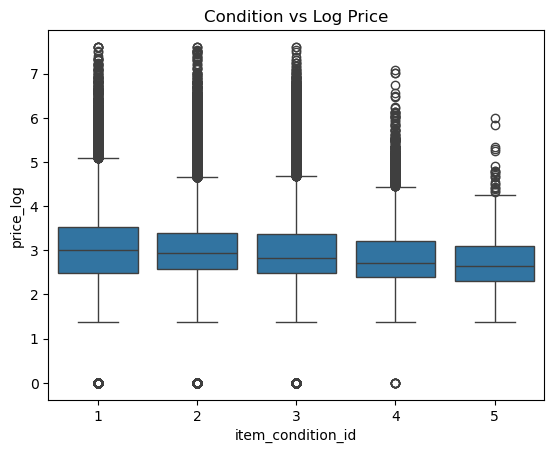

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='item_condition_id', y='price_log', data=train_filtered)
plt.title("Condition vs Log Price")
plt.show()

In [ ]:
train_filtered['item_condition_id'].value_counts()

item_condition_id
1    378041
3    240982
2    236671
4     15965
5       554
Name: count, dtype: int64

In [ ]:
train_filtered['brand_name'].isnull().mean()

np.float64(0.0)

In [ ]:
train_filtered.groupby(train_filtered['brand_name'].isnull())['price'].mean()

brand_name
False    26.690024
Name: price, dtype: float64

Condition 분석

In [ ]:
cond_dist = train_filtered['item_condition_id'].value_counts().sort_index()
cond_ratio = train_filtered['item_condition_id'].value_counts(normalize=True).sort_index()

pd.DataFrame({
    "Count": cond_dist,
    "Ratio": cond_ratio
})

,Count,Ratio
item_condition_id,,
1,378041,0.433427
2,236671,0.271345
3,240982,0.276288
4,15965,0.018304
5,554,0.000635


condition 1이가장많다. 43퍼> 거의 절반이 '신상품 또는 최상상태
23도 합치면 약 55 전체의 98퍼가 1~3구간
심한 중고상품은 거의 등록 x

이시장은 '중고 마켓이지만 신상품 중심 구조
즉 재고 처분 및 미개봉 상품 중심 



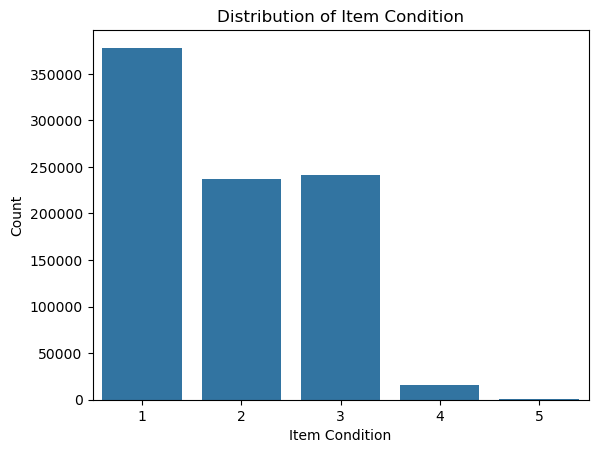

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='item_condition_id', data=train_filtered)
plt.title("Distribution of Item Condition")
plt.xlabel("Item Condition")
plt.ylabel("Count")
plt.show()

In [ ]:
train_filtered.groupby('item_condition_id')['price'].agg(['mean','median','count'])

,mean,median,count
item_condition_id,,,
1,27.616745,19.0,378041
2,26.547086,18.0,236671
3,25.720079,16.0,240982
4,21.684153,14.0,15965
5,21.543321,13.0,554


C:\Users\TG\AppData\Local\Temp\ipykernel_23660\4039674047.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_filtered['price_log'] = np.log1p(train_filtered['price'])


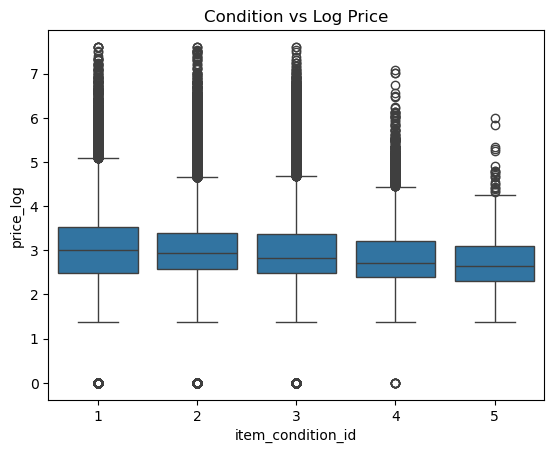

In [ ]:
import numpy as np

train_filtered['price_log'] = np.log1p(train_filtered['price'])

sns.boxplot(x='item_condition_id', y='price_log', data=train_filtered)
plt.title("Condition vs Log Price")
plt.show()

1>5로 갈수록 평균/중앙값 꾸준히 하락> 시장이 상태를 가격에 반영하고있음

차이는 크지않지만 병확한 방향성이있음
컨디션 1vs5 평균차이 약 6달러 중앙값도 19에서 13으로 하락 일관되게 감소 

박스플롯
컨디션 1이 중앙값이 가장높음
컨디션 45는 박스 자체가 아래쪽에 위치
고가 아웃라이어는 대부분 1~3에 존재 


Shipping 분석

In [ ]:
ship_dist = train_filtered['shipping'].value_counts()
ship_ratio = train_filtered['shipping'].value_counts(normalize=True)

pd.DataFrame({
    "Count": ship_dist,
    "Ratio": ship_ratio
})

,Count,Ratio
shipping,,
0,485212,0.5563
1,387001,0.4437


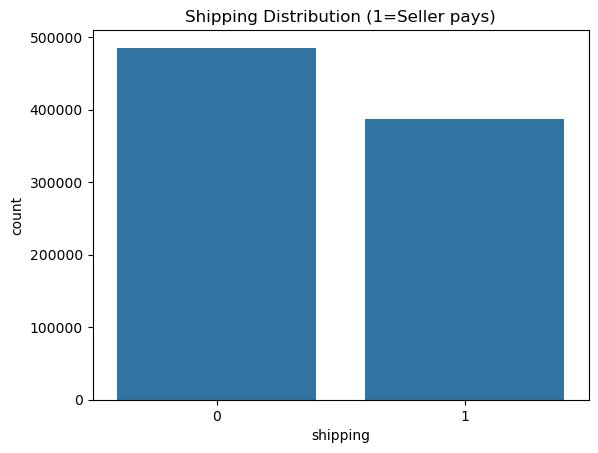

In [ ]:
sns.countplot(x='shipping', data=train_filtered)
plt.title("Shipping Distribution (1=Seller pays)")
plt.show()

구매자 부담이 더 많다. 거진 반반이긴함근데  결론은 무료배송이 기본은 아니고 무료배송 전략을 쓰는 판매자도 많고 배송비 별도 전략도 꽤 이용됨 > 배송전략이 경쟁 요소로 작용하는 시장이다.~

In [ ]:
train_filtered.groupby('shipping')['price'].agg(['mean','median','count'])

,mean,median,count
shipping,,,
0,29.474628,20.0,485212
1,23.198759,15.0,387001


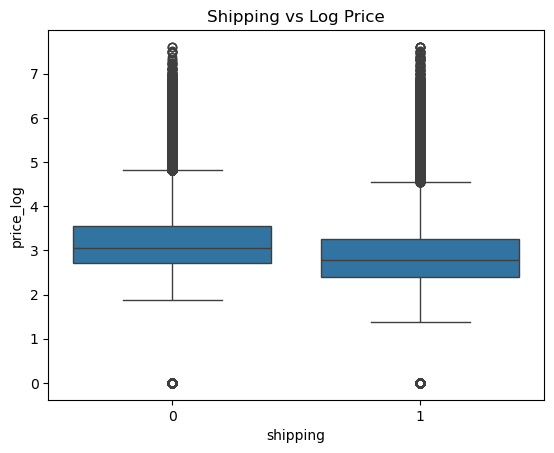

In [ ]:
sns.boxplot(x='shipping', y='price_log', data=train_filtered)
plt.title("Shipping vs Log Price")
plt.show()

무료배송 1 일때 가격이 더 낮다. 평균 6달러 차이 중앙값도 20>15

무료배송 상품은

기본 상품 가격을 낮게 설정
배송비 포함 전략 
저가 상품중심

반대로 구매자 부담 상품은
상품자체 가격이 더 높음 고가 상품에서 배송비 별도 전략사용

condition vs shipping

In [ ]:
pd.pivot_table(
    train_filtered,
    values='price',
    index='item_condition_id',
    columns='shipping',
    aggfunc=['mean','median','count']
)

mean            median         count        
shipping                   0          1      0     1       0       1
item_condition_id                                                   
1                  33.775823  22.944922   24.0  15.0  163065  214976
2                  28.079686  23.933914   19.0  15.0  149179   87492
3                  26.896207  23.328187   18.0  15.0  161547   79435
4                  22.708401  19.375993   16.0  12.0   11058    4907
5                  24.181818  16.528796   14.0  12.0     363     191

배송비 구매자 부담이 항상 가격이 더높다. 

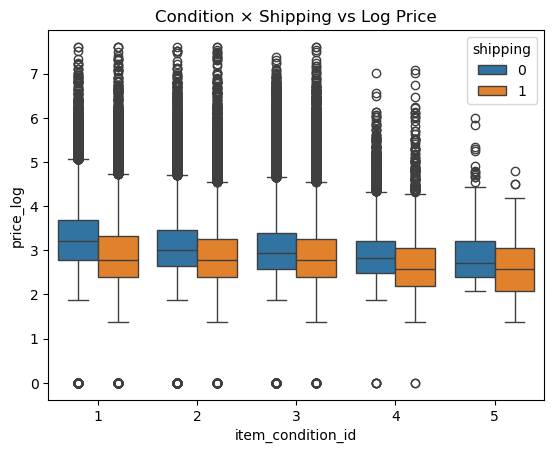

In [ ]:
sns.boxplot(
    x='item_condition_id',
    y='price_log',
    hue='shipping',
    data=train_filtered
)
plt.title("Condition × Shipping vs Log Price")
plt.show()

파란색이 항상 위에있음 
특히 컨디션 1에서 격차가 제일 크고 고가 아웃아리어 대부분이 shipping  0 

판매자 인사이트
컨디션 1 고가 전략이면 배송비 별도가능
저가 경쟁 구간은 무료배송이 기본
무료배송이 항상 유리한건아님


Condition과 Shipping을 교차 분석한 결과,
모든 상태 구간에서 배송비 구매자 부담 상품이
더 높은 평균 가격을 형성하고 있었다.
특히 Condition 1에서 가격 차이가 가장 크게 나타났으며,
이는 프리미엄 상품일수록 배송비 별도 전략이 활용됨을 시사한다.

Women vs Beauty 구조 비교

Condition 비율 비교

In [31]:
cond_cat = pd.crosstab(train_filtered['cat_1'],
                       train_filtered['item_condition_id'],
                       normalize='index')

cond_cat

item_condition_id,1,2,3,4,5
cat_1,,,,,
Beauty,0.721577,0.146535,0.12354,0.008064,0.000284
Women,0.343290,0.310388,0.32407,0.021507,0.000745


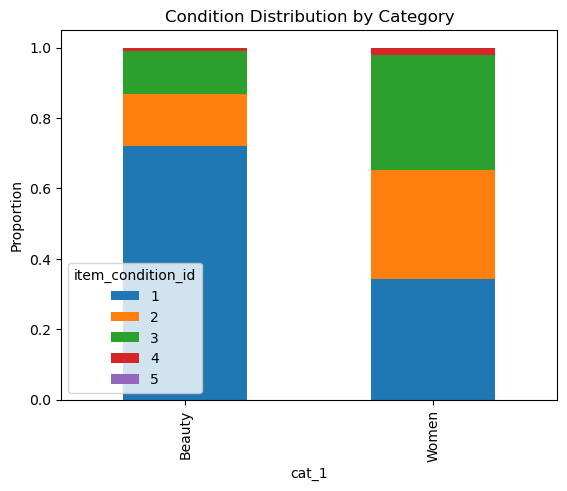

In [32]:
cond_cat.plot(kind='bar', stacked=True)
plt.title("Condition Distribution by Category")
plt.ylabel("Proportion")
plt.show()

뷰티 시장은 10개중 7개가 거의 컨디션 1 
중고개념이 거의없고 사실상 새상품중심

우먼시장은 중고 패션시장으로 컨디션 1이 34퍼
2~3이 63퍼 차지 
준신상품/중고 중심

뷰티

→ 새 상품 중심
→ 상태 경쟁 매우 중요
→ 프리미엄 가능

우먼

→ 중고 허용 시장
→ 상태 스펙트럼 넓음
→ 가격 다양성 큼

근데 이래가지고 뭐 한시장으로 볼수있겠나?

Beauty에 상품 올린다면
Condition 1 아니면 경쟁력 낮음
중고 전략 불리
“새상품 강조”는 필수

우먼에 상품올린다면 
컨디션 2~3도 경쟁력있음 상태보다 스타일/.브랜드 중요 할 수도?

In [ ]:
shipping

In [33]:
ship_cat = pd.crosstab(train_filtered['cat_1'],
                       train_filtered['shipping'],
                       normalize='index')

ship_cat

shipping,0,1
cat_1,,
Beauty,0.390347,0.609653
Women,0.608212,0.391788


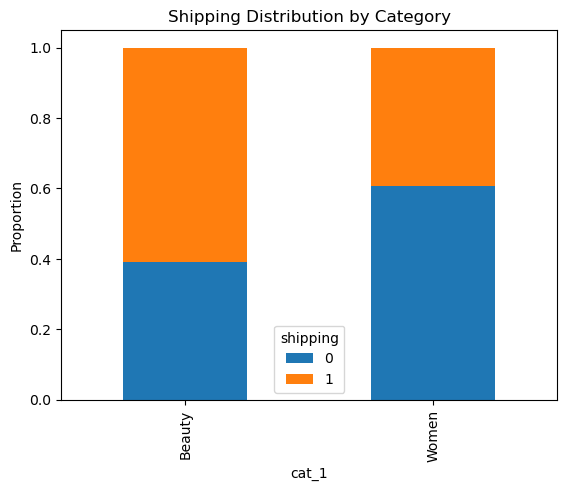

In [34]:
ship_cat.plot(kind='bar', stacked=True)
plt.title("Shipping Distribution by Category")
plt.ylabel("Proportion")
plt.show()

뷰티
 무료배송 전략이 기본값
 신상품 중심시장이고 브랜드 상품 자체 경쟁이기 때문에 배송비 포함한 가격전략이 자연스럽다..

 우먼은 배송비 별도 전략이 더많다. 
 중고 중심이고 가격 스펙트럼이 넓어서 판매가자 배송비까지 부담하지않는다. 

 둘이 다른데..?

 가격 구간 세분화 분석
 가격 구간 만들기

In [35]:
train_filtered['price_group'] = pd.qcut(
    train_filtered['price'],
    4,
    labels=['Low','Mid-Low','Mid-High','High']
)

C:\Users\TG\AppData\Local\Temp\ipykernel_24048\3587337290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_filtered['price_group'] = pd.qcut(


가격구간 × Condition (표)

In [36]:
cond_price = pd.crosstab(train_filtered['price_group'],
                         train_filtered['item_condition_id'],
                         normalize='index')

cond_price

item_condition_id,1,2,3,4,5
price_group,,,,,
Low,0.432278,0.256238,0.284938,0.025524,0.001022
Mid-Low,0.379505,0.290880,0.308413,0.020500,0.000702
Mid-High,0.440041,0.278264,0.265922,0.015371,0.000402
High,0.485291,0.259112,0.243712,0.011483,0.000402


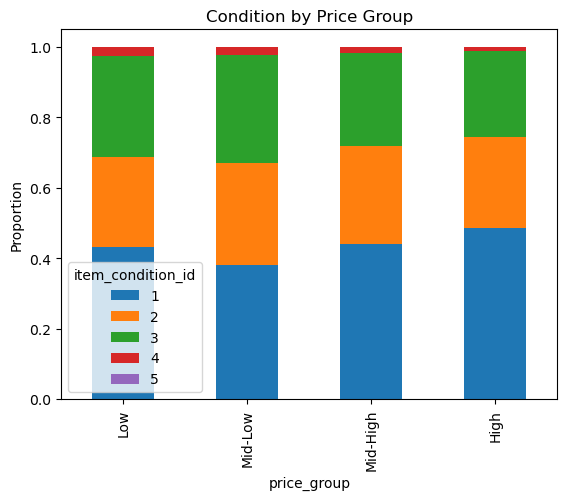

In [37]:
cond_price.plot(kind='bar', stacked=True)
plt.title("Condition by Price Group")
plt.ylabel("Proportion")
plt.show()

가격이 올라갈수록 컨디션 1 상승패턴이있긴함 물론 low는 아님
23은 중간가격대가 많음

가격구간 × Shipping (표)

In [38]:
ship_price = pd.crosstab(train_filtered['price_group'],
                         train_filtered['shipping'],
                         normalize='index')

ship_price

shipping,0,1
price_group,,
Low,0.384638,0.615362
Mid-Low,0.580149,0.419851
Mid-High,0.606696,0.393304
High,0.657269,0.342731


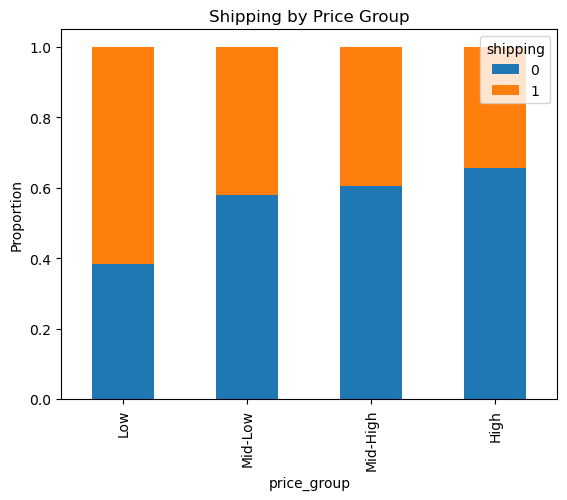

In [39]:
ship_price.plot(kind='bar', stacked=True)
plt.title("Shipping by Price Group")
plt.ylabel("Proportion")
plt.show()

가격이 올라갈수록 배송비 별도 비율이 증가한다.

무얼의미하는가
저가구간>무료배송
고가구간> 배송비별도전략
으흠